<a href="https://colab.research.google.com/github/CPernet/Semantically_Incongruent_or_Congruent_Eggplants_revised/blob/main/erps_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trial-level ERP analysis of sentence-final expectancy and semantic integration

The present reanalysis uses the N400Stimset dataset introduced by Toffolo et al. (2022), an auditory sentence-congruity ERP dataset designed to elicit semantic-integration responses to sentence-final words. In the original study, participants listened to spoken sentences with semantically congruent or incongruent endings, and the authors reported ERP effects in the Recognition Potential, N400, and LPC/P600 time ranges (Toffolo et al., 2022). The associated Dryad dataset provides the stimulus set and the high-density EEG/ERP resources used for the task, including preprocessed ERP derivative `.mat` files and corresponding trial-rejection information. :contentReference[oaicite:0]{index=0}

This notebook runs the ERP part of the Toffolo et al. (2022) N400Stimset reanalysis. The original study tested ERP responses to sentence-final congruent and incongruent words, with effects reported for the Recognition Potential (RP), N400, and Late Positive Component (LPC/P600). The present analysis keeps the sentence-final ERP focus and uses the predictor table created in the stimulus notebook to model retained ERP/EEG trials at the trial level.

This notebook belongs to the GitHub repository for the Toffolo et al. language reanalysis:  
[https://github.com/CPernet/Semantically_Incongruent_or_Congruent_Eggplants_revised](https://github.com/CPernet/Semantically_Incongruent_or_Congruent_Eggplants_revised)

The stimulus notebook created the GLM-ready table of item-level predictors. That table keeps `stim_key` as the stimulus identifier and contains predictors for each sentence-final target word, including human cloze probability, GPT-2 surprisal, LLM-derived expectancy, semantic similarity, lexical frequency, word length, phonology, syntactic complexity, and affective features.

This ERP notebook uses the processed N400Stimset ERP derivatives and epoched EEG files: subject-level ERP `.mat` files, paired `*_trialrej.tsv` files, subject event information, and EEGLAB epoch files for the CP, GA, LD, Order, and Time analysis schemes. These files contain the retained trials after preprocessing and rejection.

The notebook runs three scripts. `erp_analysis/export_erp_long.py` creates `ALL_subjects_ALL_erp_trial_lookup.tsv`, a retained-trial lookup that records the subject, analysis scheme, condition, retained-trial number, EEGLAB event information, original event row, stimulus file, and `stim_key` for every retained ERP trial. `eeg_analysis/prepare_limo_design_matrix.py` uses that lookup to create subject-specific GLM design matrices by attaching the stimulus predictors through `stim_key`. `eeg_analysis/run_limo_first_level_glm.py` pairs each subject’s epoched EEG file with the matching design matrix and estimates beta and t values for the selected predictors across channels and timepoints.

The outputs of this notebook are the retained-trial lookup, the subject-specific GLM design matrices, and the first-level EEG/ERP GLM results. These outputs test whether sentence-final expectancy, surprisal, semantic fit, lexical properties, phonological structure, syntactic complexity, and affective tone explain variation in RP, N400/PN400, and LPC/P600 activity.

In [1]:
%cd /content

!rm -rf Semantically_Incongruent_or_Congruent_Eggplants_revised
!git clone https://github.com/CPernet/Semantically_Incongruent_or_Congruent_Eggplants_revised.git

%cd /content/Semantically_Incongruent_or_Congruent_Eggplants_revised

/content
Cloning into 'Semantically_Incongruent_or_Congruent_Eggplants_revised'...
remote: Enumerating objects: 468, done.
remote: Counting objects: 100% (188/188), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 468 (delta 124), reused 69 (delta 39), pack-reused 280 (from 1)
Receiving objects: 100% (468/468), 100.95 MiB | 31.98 MiB/s, done.
Resolving deltas: 100% (272/272), done.
/content/Semantically_Incongruent_or_Congruent_Eggplants_revised


In [9]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 57.9 MB/s eta 0:00:00


In [5]:
!unzip language_outputs.zip

Archive:  language_outputs.zip
replace language_outputs/ALL_language_metrics.tsv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


**Note**: Due to their size, the N400 ERP derivatives are stored on Google Drive and mounted during notebook execution.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!unzip -o erps.zip

Archive:  erps.zip
  inflating: erps/task-N400Stimset_erp-CP_trialrej.json  
  inflating: erps/task-N400Stimset_erp-GA_filter.json  
  inflating: erps/task-N400Stimset_erp-GA_trialrej.json  
  inflating: erps/task-N400Stimset_erp-LD_trialrej.json  
  inflating: erps/task-N400Stimset_erp-Order_trialrej.json  
  inflating: erps/task-N400Stimset_erp-Time_trialrej.json  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-CP.mat  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-CP_trialrej.tsv  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-GA.mat  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-GA_trialrej.tsv  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-LD.mat  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-LD_trialrej.tsv  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-Order.mat  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-Order_trialrej.tsv  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-Time.mat  
  inflating: erps/sub-01/sub

In [6]:
%cd /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/

/content/Semantically_Incongruent_or_Congruent_Eggplants_revised


# Export retained ERP trials

This section creates the retained-trial lookup used to connect the ERP data with the stimulus predictors.

The export script reads the ERP `.mat` files, the matching `*_trialrej.tsv` files, the subject event information, and the stimulus lookup. It runs across the CP, GA, LD, Order, and Time analysis schemes.

The output is:

`ALL_subjects_ALL_erp_trial_lookup.tsv`

For each retained ERP trial, the table stores the subject, analysis scheme, condition, retained-trial number, event information, stimulus file, and `stim_key`.

In [ ]:
!python erp_analysis/export_erp_long.py \
  "/content/drive/MyDrive/N400/erps" \
  --analyses ALL \
  --subjects ALL \
  --language-metrics "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv" \
  --output-dir "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs"

Loaded 442 stimulus mappings from /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Found 104 ERP MAT files.
Using ERP root: /content/drive/MyDrive/N400/erps
Analyses: CP, GA, LD, Order, Time
Subjects: ALL
Language metrics: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Combined lookup: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv

Processing sub-01_task-N400Stimset_erp-CP.mat
  Using sub-01_task-N400Stimset_erp-CP_trialrej.tsv
  Condition 1: Congruent: Cloze Probability ≥ 96 % - 54 before rejection, 29 reported retained, 29 MAT retained
  Condition 2: Congruent: 96 % > Cloze Probability ≥ 90 % - 56 before rejection, 40 reported retained, 40 MAT retained
  Condition 3: Congruent: 90 % > Cloze Probability ≥ 80 % - 47 before rejection, 30 reported retained, 30 MAT retained
  Condition 4: Congruent: Cloze

In [ ]:
%#cd /content/Semantically_Incongruent_or_Congruent_Eggplants_revised
#!zip -r "/content/eeg_outputs.zip" "eeg_outputs"

/content/Semantically_Incongruent_or_Congruent_Eggplants_revised
  adding: eeg_outputs/ (stored 0%)
  adding: eeg_outputs/ALL_subjects_ALL_erp_trial_lookup_export_log.tsv (deflated 90%)
  adding: eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv (deflated 91%)


In [ ]:
#from google.colab import files
#files.download("/content/eeg_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
#!unzip -o eeg_outputs.zip -d /content/Semantically_Incongruent_or_Congruent_Eggplants_revised

Archive:  eeg_outputs.zip
   creating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs/
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup_export_log.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv  


In [ ]:
!python erp_analysis/export_erp_long.py \
  "/content/drive/MyDrive/N400/erps" \
  --analyses ALL \
  --subjects ALL \
  --language-metrics "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv" \
  --output-dir "/content/drive/MyDrive/N400/eeg_outputs"

Loaded 442 stimulus mappings from /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Found 104 ERP MAT files.
Using ERP root: /content/drive/MyDrive/N400/erps
Analyses: CP, GA, LD, Order, Time
Subjects: ALL
Language metrics: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Combined lookup: /content/drive/MyDrive/N400/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv

Processing sub-01_task-N400Stimset_erp-CP.mat
  Using sub-01_task-N400Stimset_erp-CP_trialrej.tsv
  Condition 1: Congruent: Cloze Probability ≥ 96 % - 54 before rejection, 29 reported retained, 29 MAT retained
  Condition 2: Congruent: 96 % > Cloze Probability ≥ 90 % - 56 before rejection, 40 reported retained, 40 MAT retained
  Condition 3: Congruent: 90 % > Cloze Probability ≥ 80 % - 47 before rejection, 30 reported retained, 30 MAT retained
  Condition 4: Congruent: Cloze Probability < 80 % - 43 before rejec

In [ ]:
!python erp_analysis/export_erp_long.py \
  "/content/drive/MyDrive/N400/erps" \
  --analyses ALL \
  --subjects ALL \
  --language-metrics "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv" \
  --output-dir "/content/drive/MyDrive/N400/eeg_outputs"

Loaded 442 stimulus mappings from /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Found 104 ERP MAT files.
Using ERP root: /content/drive/MyDrive/N400/erps
Analyses: CP, GA, LD, Order, Time
Subjects: ALL
Language metrics: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Combined lookup: /content/drive/MyDrive/N400/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv

Processing sub-01_task-N400Stimset_erp-CP.mat
  Using sub-01_task-N400Stimset_erp-CP_trialrej.tsv
  Condition 1: Congruent: Cloze Probability ≥ 96 % - 54 before rejection, 29 reported retained, 29 MAT retained
  Condition 2: Congruent: 96 % > Cloze Probability ≥ 90 % - 56 before rejection, 40 reported retained, 40 MAT retained
  Condition 3: Congruent: 90 % > Cloze Probability ≥ 80 % - 47 before rejection, 30 reported retained, 30 MAT retained
  Condition 4: Congruent: Cloze Probability < 80 % - 43 before rejec

term,meaning
Condition retention %,Percentage of trials retained after artifact rejection for one exported condition.
Condition imbalance,"Difference between the highest and lowest condition retention percentage within the same subject, analysis, and source file."
Difference from analysis mean,How far each condition's retention is above or below the average retention of its own analysis.


subject,analysis,plot_label,condition_label,retained_trial,stimulus_row,stim_key,trial_type
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,1,17,sound17,NPI
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,2,23,sound23,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,3,133,sound133,NPI
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,4,164,sound164,NPI
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,5,215,sound215,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,6,345,sound345,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,7,351,sound351,NPI
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,8,357,sound357,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,9,381,sound381,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,10,414,sound414,NPC


plot_label,condition_label
CP C1,Congruent: Cloze Probability ≥ 96 %
CP C2,Congruent: 96 % > Cloze Probability ≥ 90 %
CP C3,Congruent: 90 % > Cloze Probability ≥ 80 %
CP C4,Congruent: Cloze Probability < 80 %
CP C5,Incongruent: Cloze Probability ≥ 96 %
CP C6,Incongruent: 96 % > Cloze Probability ≥ 90 %
CP C7,Incongruent: 90 % > Cloze Probability ≥ 80 %
CP C8,Incongruent: Cloze Probability < 80 %
GA C1,Congruent
GA C2,Incongruent


plot_label,mean_pct,sd_pct,min_pct,max_pct,diff_from_analysis_mean_pp
CP C1,84.81,15.99,40.74,98.15,-0.79
CP C2,85.98,13.50,48.21,98.21,0.38
CP C3,85.21,14.42,53.19,97.87,-0.39
CP C4,84.53,17.63,32.56,100.00,-1.07
CP C5,86.64,16.82,34.55,100.00,1.04
CP C6,86.70,12.69,55.36,98.21,1.10
CP C7,83.94,16.06,40.43,95.74,-1.66
CP C8,87.02,14.11,54.76,100.00,1.42
GA C1,83.39,17.85,34.09,99.00,-0.21
GA C2,83.81,17.76,35.91,97.27,0.21


analysis,mean_imbalance_pp,sd_imbalance_pp,min_imbalance_pp,max_imbalance_pp
CP,13.15,6.21,4.73,26.37
GA,3.06,2.72,0.00,9.00
LD,7.38,3.54,1.91,14.79
Order,8.10,6.21,1.88,28.28
Time,17.71,12.37,5.46,53.53


statistic,value
Retained ERP-trial rows,35751.00
Subjects represented,24.00
Analyses represented,5.00
ERP MAT files represented,104.00
Unique stimulus keys,442.00
Unique stimulus files,442.00
Missing stim_key,0.00
Missing stim_file,0.00
Stimulus row minimum,1.00
Stimulus row maximum,442.00


analysis,congruence_group,mean_pct,sd_pct,min_pct,max_pct
CP,Congruent,85.14,15.18,32.56,100.00
CP,Incongruent,86.07,14.77,34.55,100.00
GA,Congruent,83.39,17.85,34.09,99.00
GA,Incongruent,83.81,17.76,35.91,97.27
LD,Congruent,85.87,15.28,42.03,100.00
LD,Incongruent,86.97,14.43,46.56,100.00
Order,Incongruent,86.54,14.90,42.42,101.02
Time,Congruent,86.06,16.27,25.00,101.96
Time,Incongruent,87.04,15.69,28.57,102.04


congruence_group,analysis,congruent_minus_incongruent_pp
,CP,-0.93
,GA,-0.42
,LD,-1.10
,Order,NaN
,Time,-0.98


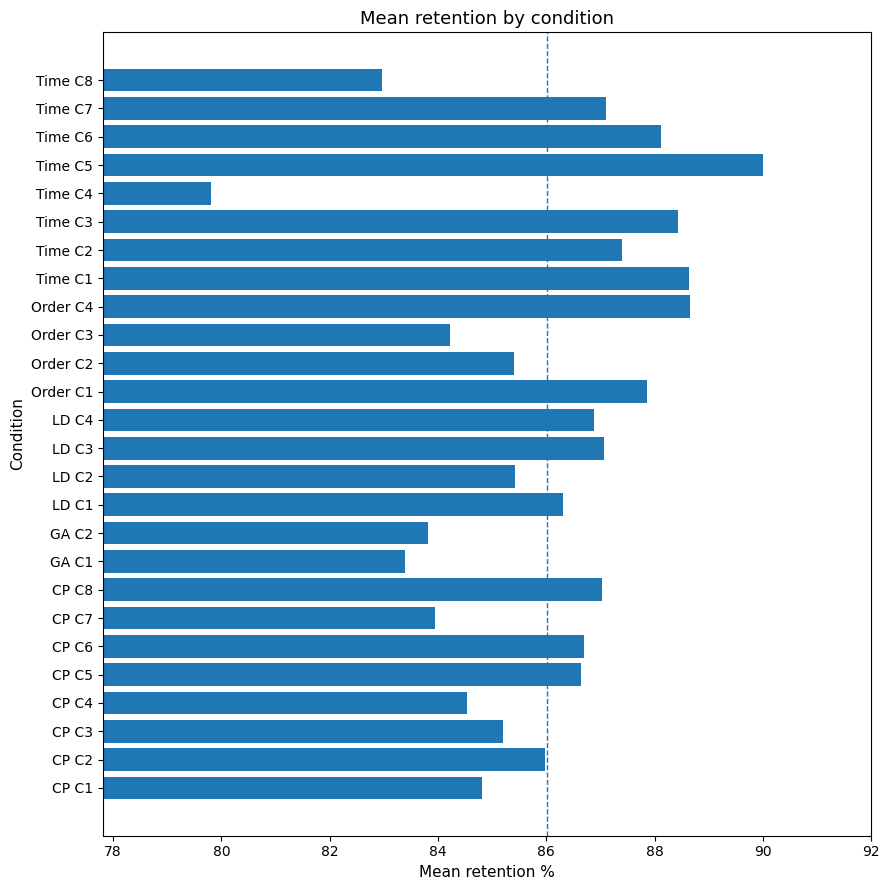

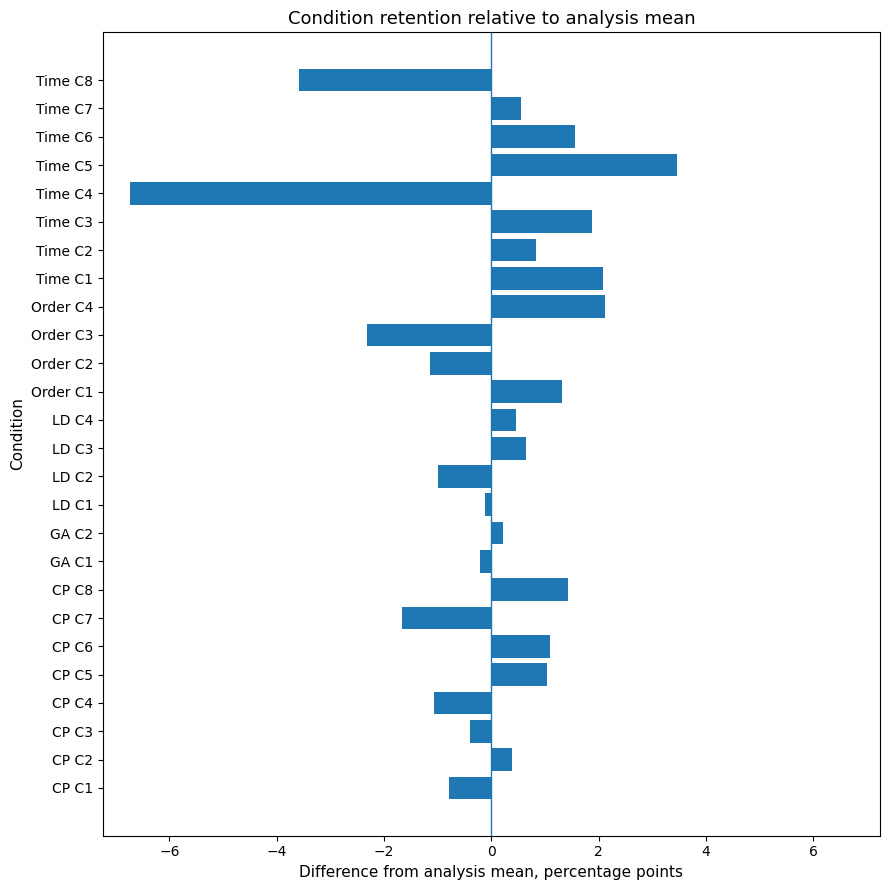

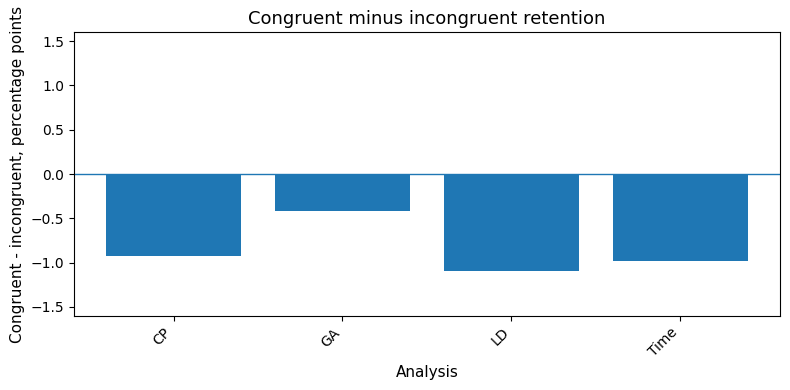

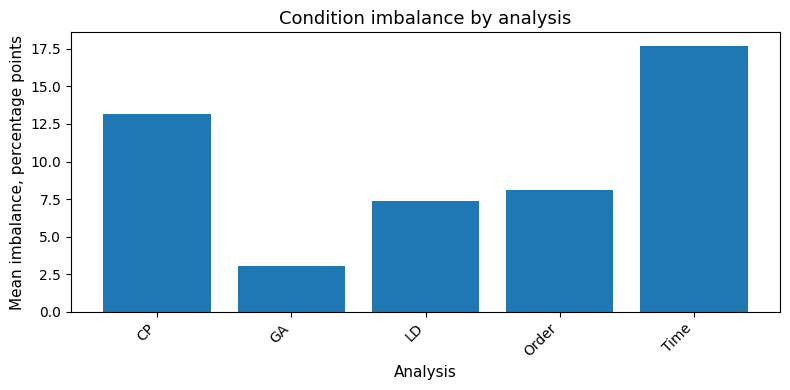

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# ============================================================
# Input
# ============================================================

lookup_path = "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv"
lookup = pd.read_csv(lookup_path, sep="\t")

# ============================================================
# Plot text sizes
# ============================================================

plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ============================================================
# Display helper
# ============================================================

def show_table(df, title=None, max_height="420px"):
    if title is not None:
        display(HTML(f"""
        <h3 style="
            margin-top: 18px;
            margin-bottom: 8px;
            font-weight: bold;
        ">
            {title}
        </h3>
        """))

    html = df.to_html(index=False, escape=False)

    display(HTML(f"""
    <div style="
        max-height: {max_height};
        overflow-y: auto;
        overflow-x: auto;
        border: 1px solid #999999;
        padding: 8px;
        font-size: 13px;
        margin-bottom: 18px;
    ">
        <style>
            table {{
                border-collapse: collapse;
                width: 100%;
            }}

            th {{
                border: 1px solid #777777;
                padding: 7px;
                text-align: left;
                vertical-align: top;
                white-space: normal;
                word-wrap: break-word;
                max-width: 280px;
                background-color: #222222 !important;
                color: #ffffff !important;
                position: sticky;
                top: 0;
                z-index: 2;
                font-weight: bold;
            }}

            td {{
                border: 1px solid #dddddd;
                padding: 6px;
                text-align: left;
                vertical-align: top;
                white-space: normal;
                word-wrap: break-word;
                max-width: 280px;
            }}
        </style>
        {html}
    </div>
    """))

display(HTML("""
<h2 style="font-weight: bold; margin-bottom: 16px;">
ERP lookup export: first rows and statistical QC
</h2>
"""))

# ============================================================
# Build condition-level dataset
# ============================================================

condition_cells = (
    lookup[
        [
            "subject",
            "analysis",
            "source_file",
            "condition",
            "condition_label",
            "before_trial_rejection",
            "after_trial_rejection_mat",
        ]
    ]
    .drop_duplicates()
    .copy()
)

condition_cells["retention_pct"] = (
    condition_cells["after_trial_rejection_mat"]
    / condition_cells["before_trial_rejection"]
    * 100
)

condition_cells["plot_label"] = (
    condition_cells["analysis"].astype(str)
    + " C"
    + condition_cells["condition"].astype(str)
)

def get_congruence_group(label):
    label = str(label).lower()

    if "incongruent" in label or "inongruent" in label:
        return "Incongruent"

    if "congruent" in label:
        return "Congruent"

    return "Other"

condition_cells["congruence_group"] = condition_cells["condition_label"].apply(
    get_congruence_group
)

# ============================================================
# QC meaning table
# ============================================================

meaning_table = pd.DataFrame(
    {
        "term": [
            "Condition retention %",
            "Condition imbalance",
            "Difference from analysis mean",
        ],
        "meaning": [
            "Percentage of trials retained after artifact rejection for one exported condition.",
            "Difference between the highest and lowest condition retention percentage within the same subject, analysis, and source file.",
            "How far each condition's retention is above or below the average retention of its own analysis.",
        ],
    }
)

show_table(
    meaning_table,
    "QC term meanings",
)

# ============================================================
# 1. First rows of exported lookup
# ============================================================

first_rows = lookup[
    [
        "subject",
        "analysis",
        "condition",
        "condition_label",
        "retained_trial",
        "stimulus_row",
        "stim_key",
        "trial_type",
    ]
].head(15).copy()

first_rows["plot_label"] = (
    first_rows["analysis"].astype(str)
    + " C"
    + first_rows["condition"].astype(str)
)

first_rows = first_rows[
    [
        "subject",
        "analysis",
        "plot_label",
        "condition_label",
        "retained_trial",
        "stimulus_row",
        "stim_key",
        "trial_type",
    ]
]

show_table(
    first_rows,
    "1. First rows of exported lookup",
)

# ============================================================
# 2. Condition-label key for plot labels
# ============================================================

condition_key = (
    lookup[
        [
            "analysis",
            "condition",
            "condition_label",
        ]
    ]
    .drop_duplicates()
    .sort_values(["analysis", "condition"])
    .reset_index(drop=True)
)

condition_key["plot_label"] = (
    condition_key["analysis"].astype(str)
    + " C"
    + condition_key["condition"].astype(str)
)

condition_key = condition_key[
    [
        "plot_label",
        "condition_label",
    ]
]

show_table(
    condition_key,
    "2. Condition-label key for plot labels",
)

# ============================================================
# 3. Retention statistics by condition
# ============================================================

condition_stats = (
    condition_cells
    .groupby(["analysis", "condition", "plot_label"])["retention_pct"]
    .agg(
        mean_pct="mean",
        sd_pct="std",
        min_pct="min",
        max_pct="max",
    )
    .reset_index()
    .sort_values(["analysis", "condition"])
)

for col in ["mean_pct", "sd_pct", "min_pct", "max_pct"]:
    condition_stats[col] = condition_stats[col].round(2)

analysis_mean_retention = (
    condition_cells
    .groupby("analysis")["retention_pct"]
    .mean()
    .reset_index(name="analysis_mean_pct")
)

condition_stats = condition_stats.merge(
    analysis_mean_retention,
    on="analysis",
    how="left",
)

condition_stats["diff_from_analysis_mean_pp"] = (
    condition_stats["mean_pct"]
    - condition_stats["analysis_mean_pct"]
).round(2)

condition_stats_compact = condition_stats[
    [
        "plot_label",
        "mean_pct",
        "sd_pct",
        "min_pct",
        "max_pct",
        "diff_from_analysis_mean_pp",
    ]
]

show_table(
    condition_stats_compact,
    "3. Retention statistics by condition",
)

# ============================================================
# 4. Condition imbalance statistics by analysis
# ============================================================

condition_imbalance_by_file_analysis = (
    condition_cells
    .groupby(["subject", "analysis", "source_file"])["retention_pct"]
    .agg(
        min_retention_pct="min",
        max_retention_pct="max",
    )
    .reset_index()
)

condition_imbalance_by_file_analysis["condition_imbalance_pp"] = (
    condition_imbalance_by_file_analysis["max_retention_pct"]
    - condition_imbalance_by_file_analysis["min_retention_pct"]
)

imbalance_stats = (
    condition_imbalance_by_file_analysis
    .groupby("analysis")["condition_imbalance_pp"]
    .agg(
        mean_imbalance_pp="mean",
        sd_imbalance_pp="std",
        min_imbalance_pp="min",
        max_imbalance_pp="max",
    )
    .reset_index()
    .sort_values("analysis")
)

for col in [
    "mean_imbalance_pp",
    "sd_imbalance_pp",
    "min_imbalance_pp",
    "max_imbalance_pp",
]:
    imbalance_stats[col] = imbalance_stats[col].round(2)

show_table(
    imbalance_stats,
    "4. Condition imbalance statistics by analysis",
)

# ============================================================
# 5. Overall statistical QC summary
# ============================================================

overall_summary = pd.DataFrame(
    {
        "statistic": [
            "Retained ERP-trial rows",
            "Subjects represented",
            "Analyses represented",
            "ERP MAT files represented",
            "Unique stimulus keys",
            "Unique stimulus files",
            "Missing stim_key",
            "Missing stim_file",
            "Stimulus row minimum",
            "Stimulus row maximum",
            "Mean condition retention %",
            "SD condition retention %",
            "Minimum condition retention %",
            "Maximum condition retention %",
            "Mean condition imbalance, percentage points",
            "Maximum condition imbalance, percentage points",
        ],
        "value": [
            len(lookup),
            lookup["subject"].nunique(),
            lookup["analysis"].nunique(),
            lookup["source_file"].nunique(),
            lookup["stim_key"].nunique(),
            lookup["stim_file"].nunique(),
            int(lookup["stim_key"].isna().sum()),
            int(lookup["stim_file"].isna().sum()),
            int(lookup["stimulus_row"].min()),
            int(lookup["stimulus_row"].max()),
            round(condition_cells["retention_pct"].mean(), 2),
            round(condition_cells["retention_pct"].std(), 2),
            round(condition_cells["retention_pct"].min(), 2),
            round(condition_cells["retention_pct"].max(), 2),
            round(condition_imbalance_by_file_analysis["condition_imbalance_pp"].mean(), 2),
            round(condition_imbalance_by_file_analysis["condition_imbalance_pp"].max(), 2),
        ],
    }
)

show_table(
    overall_summary,
    "5. Overall statistical QC summary",
)

# ============================================================
# 6. Congruent vs incongruent retention statistics
# ============================================================

congruence_stats = (
    condition_cells[
        condition_cells["congruence_group"].isin(["Congruent", "Incongruent"])
    ]
    .groupby(["analysis", "congruence_group"])["retention_pct"]
    .agg(
        mean_pct="mean",
        sd_pct="std",
        min_pct="min",
        max_pct="max",
    )
    .reset_index()
    .sort_values(["analysis", "congruence_group"])
)

for col in ["mean_pct", "sd_pct", "min_pct", "max_pct"]:
    congruence_stats[col] = congruence_stats[col].round(2)

show_table(
    congruence_stats,
    "6. Congruent vs incongruent retention statistics",
)

congruence_pivot = (
    congruence_stats
    .pivot(
        index="analysis",
        columns="congruence_group",
        values="mean_pct",
    )
    .sort_index()
)

if "Congruent" in congruence_pivot.columns and "Incongruent" in congruence_pivot.columns:
    congruence_pivot["congruent_minus_incongruent_pp"] = (
        congruence_pivot["Congruent"]
        - congruence_pivot["Incongruent"]
    )
else:
    congruence_pivot["congruent_minus_incongruent_pp"] = np.nan

congruence_difference_table = (
    congruence_pivot[["congruent_minus_incongruent_pp"]]
    .reset_index()
)

congruence_difference_table["congruent_minus_incongruent_pp"] = (
    congruence_difference_table["congruent_minus_incongruent_pp"].round(2)
)

show_table(
    congruence_difference_table,
    "7. Congruent minus incongruent retention difference",
)

# ============================================================
# 7. Plots
# ============================================================

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
Plots
</h3>
"""))

# ------------------------------------------------------------
# Plot 1. Mean retention by condition
# ------------------------------------------------------------

condition_plot = condition_stats.copy().sort_values(["analysis", "condition"])

x_min = max(0, condition_plot["mean_pct"].min() - 2)
x_max = min(100, condition_plot["mean_pct"].max() + 2)

plt.figure(figsize=(9, 9))
plt.barh(
    condition_plot["plot_label"],
    condition_plot["mean_pct"],
)
plt.xlim(x_min, x_max)
plt.axvline(
    condition_plot["mean_pct"].mean(),
    linestyle="--",
    linewidth=1,
)
plt.xlabel("Mean retention %")
plt.ylabel("Condition")
plt.title("Mean retention by condition")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2. Difference from analysis mean
# ------------------------------------------------------------

diff_plot = condition_stats.copy().sort_values(["analysis", "condition"])

max_abs_diff = abs(diff_plot["diff_from_analysis_mean_pp"]).max()
if pd.isna(max_abs_diff) or max_abs_diff == 0:
    max_abs_diff = 1

plt.figure(figsize=(9, 9))
plt.barh(
    diff_plot["plot_label"],
    diff_plot["diff_from_analysis_mean_pp"],
)
plt.axvline(0, linewidth=1)
plt.xlim(-max_abs_diff - 0.5, max_abs_diff + 0.5)
plt.xlabel("Difference from analysis mean, percentage points")
plt.ylabel("Condition")
plt.title("Condition retention relative to analysis mean")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 3. Congruent minus incongruent retention
# ------------------------------------------------------------

congruence_diff_plot = (
    congruence_difference_table
    .dropna()
    .copy()
)

if len(congruence_diff_plot) > 0:
    max_abs_cong = abs(
        congruence_diff_plot["congruent_minus_incongruent_pp"]
    ).max()

    if pd.isna(max_abs_cong) or max_abs_cong == 0:
        max_abs_cong = 1

    plt.figure(figsize=(8, 4))
    plt.bar(
        congruence_diff_plot["analysis"],
        congruence_diff_plot["congruent_minus_incongruent_pp"],
    )
    plt.axhline(0, linewidth=1)
    plt.ylim(-max_abs_cong - 0.5, max_abs_cong + 0.5)
    plt.xlabel("Analysis")
    plt.ylabel("Congruent - incongruent, percentage points")
    plt.title("Congruent minus incongruent retention")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Plot 4. Condition imbalance by analysis
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))
plt.bar(
    imbalance_stats["analysis"],
    imbalance_stats["mean_imbalance_pp"],
)
plt.xlabel("Analysis")
plt.ylabel("Mean imbalance, percentage points")
plt.title("Condition imbalance by analysis")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Build subject-specific GLM design matrices

This section creates the design matrices used in the first-level ERP/EEG GLM.

The script combines the retained-trial lookup with the GLM-ready stimulus predictor table using `stim_key`. Each output design matrix contains the retained trials for one subject and one ERP analysis scheme, with the corresponding language predictors attached to each epoch.

In [ ]:
import pandas as pd

trial_lookup = "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv"
predictors = "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics_GLM.tsv"
output_dir = "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices"

lookup = pd.read_csv(trial_lookup, sep="\t")

analyses = (
    lookup["analysis"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Analyses found:", analyses)

for analysis in analyses:
    subjects = (
        lookup.loc[lookup["analysis"].eq(analysis), "subject"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    subjects_arg = ",".join(subjects)

    print("\n========================================")
    print("Running analysis:", analysis)
    print("Subjects:", subjects_arg)
    print("Number of subjects:", len(subjects))
    print("========================================")

    !python erp_analysis/prepare_limo_design_matrix.py \
      --trial-lookup "{trial_lookup}" \
      --predictors "{predictors}" \
      --analysis "{analysis}" \
      --subjects "{subjects_arg}" \
      --output-dir "{output_dir}"

Analyses found: ['CP', 'GA', 'LD', 'Order', 'Time']

Running analysis: CP
Subjects: sub-01,sub-02,sub-03,sub-04,sub-06,sub-07,sub-08,sub-09,sub-11,sub-12,sub-13,sub-14,sub-16,sub-17,sub-19,sub-20,sub-21,sub-22,sub-23,sub-24
Number of subjects: 20

Design-matrix validation
------------------------
Subject: sub-01
Analysis: CP
Rows: 237
Unique stimuli: 214
Predictor columns: 19
Rows with any missing predictor value: 0
Saved design matrix: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-01_erp-CP_design_matrix.tsv

Design-matrix validation
------------------------
Subject: sub-02
Analysis: CP
Rows: 375
Unique stimuli: 213
Predictor columns: 19
Rows with any missing predictor value: 0
Saved design matrix: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-02_erp-CP_design_matrix.tsv

Design-matrix validation
------------------------
Subject: sub-03
Analysis: CP
Rows: 182
Unique stimuli: 140
Predictor columns: 

predictor,construct
target_dur(s),Target stimulus duration.
human_cp,Human cloze probability; target predictability based on human responses.
n_words_sentence,Sentence length.
target_n_letters,Orthographic length of the target word.
target_zipf_frequency,Lexical frequency of the target word on the Zipf scale.
target_n_phonemes,Phonological length of the target word.
target_valence,Affective valence of the target word.
target_arousal,Affective arousal associated with the target word.
target_dominance,Affective dominance/control rating associated with the target word.
llm_cp,Model-estimated cloze probability; computational predictability of the target.


condition_plot_label,condition_label
CP C1,Congruent: Cloze Probability ≥ 96 %
CP C2,Congruent: 96 % > Cloze Probability ≥ 90 %
CP C3,Congruent: 90 % > Cloze Probability ≥ 80 %
CP C4,Congruent: Cloze Probability < 80 %
CP C5,Incongruent: Cloze Probability ≥ 96 %
CP C6,Incongruent: 96 % > Cloze Probability ≥ 90 %
CP C7,Incongruent: 90 % > Cloze Probability ≥ 80 %
CP C8,Incongruent: Cloze Probability < 80 %
GA C1,Congruent
GA C2,Incongruent


subject,analysis,condition_plot_label,condition_label,eeg_trial,stim_key,trial_type,human_cp,llm_cp,context_target_similarity,target_surprisal_bits,sentence_mean_surprisal,sentence_perplexity,syntax_mean_dependency_distance,context_shift_index
sub-01,GA,GA C1,Congruent,1,sound15,NPI,0.597765,-0.385975,-0.375933,0.787750,0.567603,-0.077768,-0.662264,0.744812
sub-01,GA,GA C1,Congruent,2,sound17,NPI,0.387850,-0.385732,-1.389929,0.346099,-0.555881,-0.202520,1.061471,1.111141
sub-01,GA,GA C1,Congruent,3,sound23,NPC,-1.059655,-0.114383,-1.346104,-1.033448,-0.812730,-0.212846,1.636049,0.200115
sub-01,GA,GA C1,Congruent,4,sound60,NPC,0.912637,-0.369618,-1.627625,-0.472301,-0.743968,-0.210421,0.793334,0.739462
sub-01,GA,GA C1,Congruent,5,sound68,NPI,0.648193,-0.385882,-1.213922,0.505851,0.203302,-0.139762,0.257061,1.100736
sub-01,GA,GA C1,Congruent,6,sound70,NPI,0.757604,-0.386004,-0.227157,2.092820,0.815410,-0.014477,1.176386,1.484896
sub-01,GA,GA C1,Congruent,7,sound86,NPI,-0.420800,-0.384597,-1.169210,0.018301,-0.618482,-0.205375,0.257061,0.760064
sub-01,GA,GA C1,Congruent,8,sound115,NPC,0.707493,-0.349649,-1.209735,-0.631551,-0.846238,-0.213949,1.463676,0.370065
sub-01,GA,GA C1,Congruent,9,sound117,NPI,-1.890467,-0.385987,0.992645,0.896076,1.443456,0.281781,-1.029995,-0.061809
sub-01,GA,GA C1,Congruent,10,sound119,NPI,-1.646012,-0.383046,-1.308288,-0.130183,-0.583771,-0.203822,-0.662264,0.754043


predictor,mean,sd,min,max,missing_values
target_dur(s),0.000,0.993,-3.143,3.757,0
human_cp,0.004,0.958,-4.808,0.913,0
n_words_sentence,0.017,0.992,-1.645,1.587,0
target_n_letters,-0.008,0.977,-1.399,5.070,0
target_zipf_frequency,0.009,0.994,-2.854,3.216,0
target_n_phonemes,-0.004,0.974,-2.773,5.614,0
target_valence,0.004,0.997,-2.638,2.117,0
target_arousal,0.001,0.992,-1.838,2.993,0
target_dominance,0.016,0.992,-2.064,3.153,0
llm_cp,0.011,1.021,-0.386,4.855,0


analysis,condition_plot_label,condition_label,predictor,mean,sd
CP,CP C1,Congruent: Cloze Probability ≥ 96 %,target_dur(s),-0.090,0.961
CP,CP C2,Congruent: 96 % > Cloze Probability ≥ 90 %,target_dur(s),-0.015,1.048
CP,CP C3,Congruent: 90 % > Cloze Probability ≥ 80 %,target_dur(s),0.018,1.002
CP,CP C4,Congruent: Cloze Probability < 80 %,target_dur(s),-0.002,1.092
CP,CP C5,Incongruent: Cloze Probability ≥ 96 %,target_dur(s),0.075,0.944
CP,CP C6,Incongruent: 96 % > Cloze Probability ≥ 90 %,target_dur(s),0.044,0.891
CP,CP C7,Incongruent: 90 % > Cloze Probability ≥ 80 %,target_dur(s),0.031,1.013
CP,CP C8,Incongruent: Cloze Probability < 80 %,target_dur(s),-0.073,0.996
GA,GA C1,Congruent,target_dur(s),-0.021,1.021
GA,GA C2,Incongruent,target_dur(s),0.008,0.972


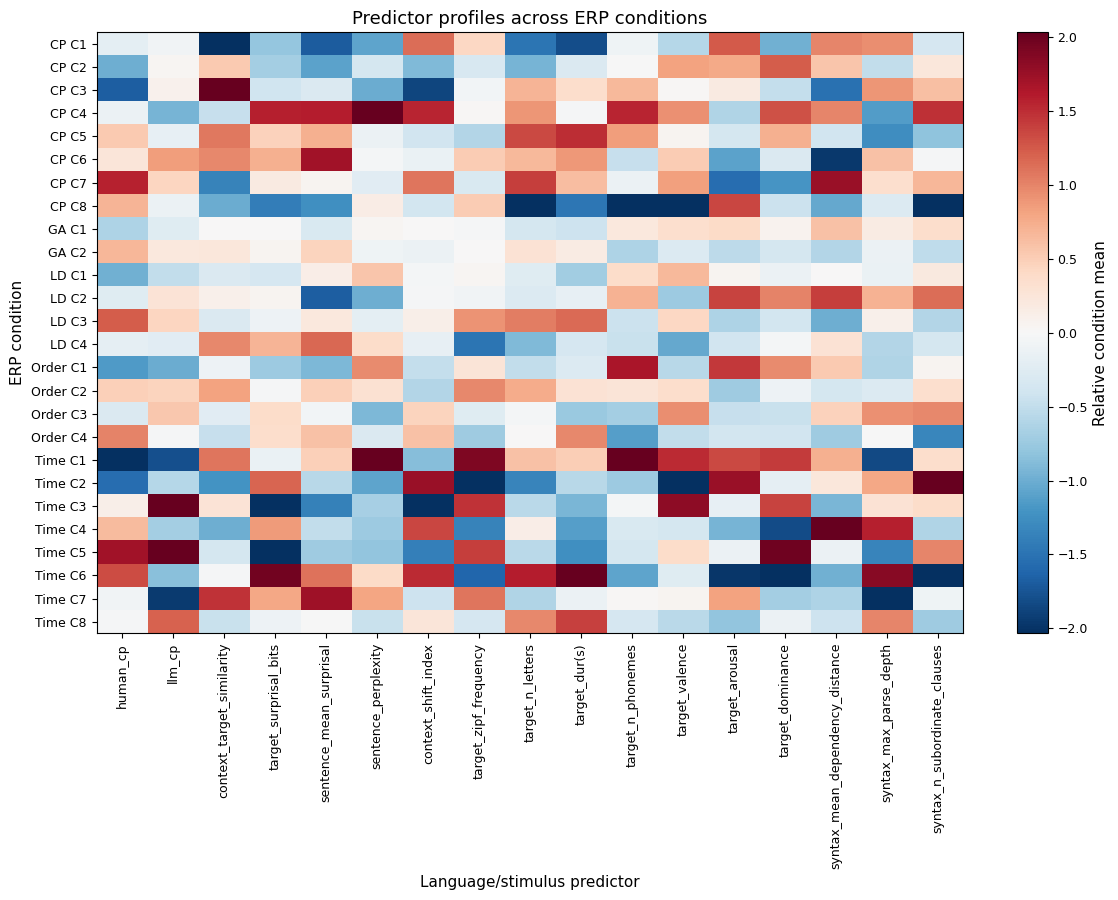

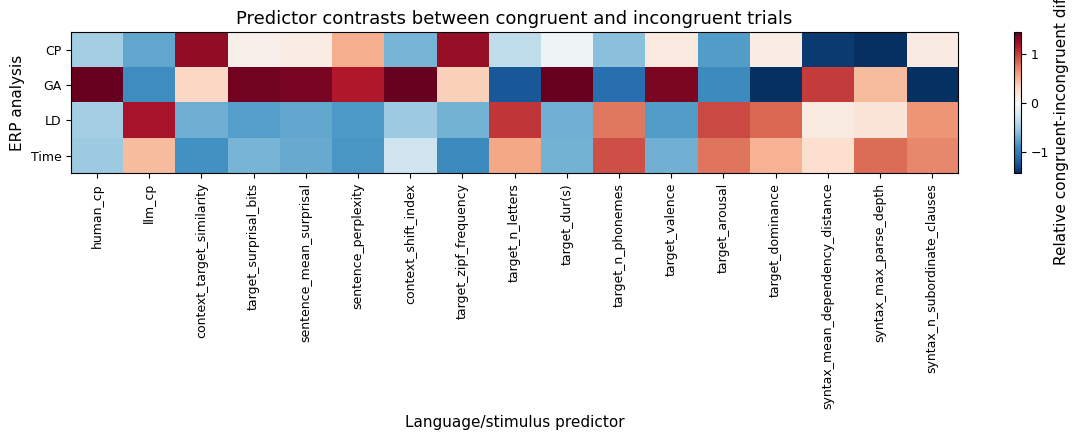

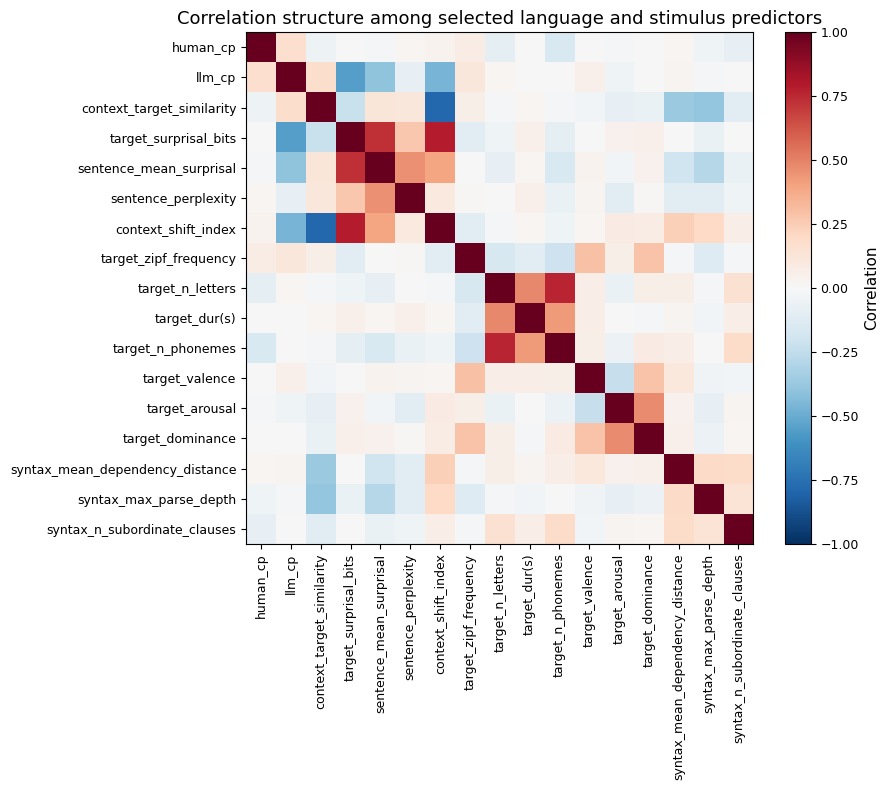

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, HTML

# ============================================================
# Input paths
# ============================================================

matrix_dir = Path("/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices")
predictors_path = Path(
    "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/"
    "language_outputs/ALL_language_metrics_GLM.tsv"
)

example_matrix_path = matrix_dir / "sub-01_erp-GA_design_matrix.tsv"

if not example_matrix_path.exists():
    matrix_files_check = sorted(matrix_dir.glob("*_design_matrix.tsv"))
    if len(matrix_files_check) == 0:
        raise FileNotFoundError(f"No design matrix files found in: {matrix_dir}")
    example_matrix_path = matrix_files_check[0]

# ============================================================
# Display helper
# ============================================================

def show_table(df, title=None, max_height="420px", wrap=True):
    if title is not None:
        display(HTML(f"""
        <h3 style="
            margin-top: 18px;
            margin-bottom: 8px;
            font-weight: bold;
        ">
            {title}
        </h3>
        """))

    html = df.to_html(index=False, escape=False)

    if wrap:
        td_style = """
            white-space: normal;
            word-break: normal;
            overflow-wrap: normal;
            max-width: 420px;
        """
    else:
        td_style = """
            white-space: nowrap;
            word-break: normal;
            overflow-wrap: normal;
            max-width: none;
        """

    display(HTML(f"""
    <div style="
        max-height: {max_height};
        overflow-y: auto;
        overflow-x: auto;
        border: 1px solid #999999;
        padding: 8px;
        font-size: 13px;
        margin-bottom: 18px;
        width: 100%;
    ">
        <style>
            table {{
                border-collapse: collapse;
                width: auto;
                min-width: 100%;
            }}

            th {{
                border: 1px solid #777777;
                padding: 7px;
                text-align: left;
                vertical-align: top;
                white-space: nowrap;
                background-color: #222222 !important;
                color: #ffffff !important;
                position: sticky;
                top: 0;
                z-index: 2;
                font-weight: bold;
            }}

            td {{
                border: 1px solid #dddddd;
                padding: 6px;
                text-align: left;
                vertical-align: top;
                {td_style}
            }}
        </style>
        {html}
    </div>
    """))

plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

display(HTML("""
<h2 style="font-weight: bold; margin-bottom: 16px;">
LIMO design matrices: ERP trial-level predictors for GLM modelling
</h2>
"""))

display(HTML("""
<p>
The LIMO design-matrix output adds the 19 language and stimulus-derived GLM predictors
to the retained ERP-trial lookup by matching each retained EEG trial to its stimulus through
<code>stim_key</code>. Each generated matrix is specific to one subject and one ERP analysis:
rows are retained EEG trials, and predictor columns are the explanatory variables used for
LIMO/GLM modelling.
</p>
"""))

# ============================================================
# Load generated design matrices
# ============================================================

matrix_files = sorted(matrix_dir.glob("*_design_matrix.tsv"))

if len(matrix_files) == 0:
    raise FileNotFoundError(f"No design matrix files found in: {matrix_dir}")

all_matrices = []

for path in matrix_files:
    df = pd.read_csv(path, sep="\t")
    df["matrix_file"] = path.name
    all_matrices.append(df)

matrices = pd.concat(all_matrices, ignore_index=True)

example_matrix = pd.read_csv(example_matrix_path, sep="\t")

# ============================================================
# Load predictor source table and define predictor columns
# ============================================================

predictor_source = pd.read_csv(
    predictors_path,
    sep=None,
    engine="python",
)

if "stim_key" not in predictor_source.columns:
    raise ValueError("The predictor source table does not contain stim_key.")

predictor_columns_from_source = [
    col for col in predictor_source.columns
    if col != "stim_key"
]

numeric_predictor_cols = []

for col in predictor_columns_from_source:
    if col in matrices.columns:
        matrices[col] = pd.to_numeric(matrices[col], errors="coerce")
        if matrices[col].notna().sum() > 0:
            numeric_predictor_cols.append(col)

for col in numeric_predictor_cols:
    if col in example_matrix.columns:
        example_matrix[col] = pd.to_numeric(example_matrix[col], errors="coerce")

# ============================================================
# Add short condition labels for readable heatmaps
# ============================================================

matrices["condition_plot_label"] = (
    matrices["analysis"].astype(str)
    + " C"
    + matrices["condition"].astype(str)
)

condition_key = (
    matrices[
        [
            "analysis",
            "condition",
            "condition_plot_label",
            "condition_label",
        ]
    ]
    .drop_duplicates()
    .sort_values(["analysis", "condition"])
    .reset_index(drop=True)
)

condition_key = condition_key[
    [
        "condition_plot_label",
        "condition_label",
    ]
]

# ============================================================
# 1. Predictor constructs
# ============================================================

predictor_constructs = {
    "target_dur(s)": "Target stimulus duration.",
    "human_cp": "Human cloze probability; target predictability based on human responses.",
    "n_words_sentence": "Sentence length.",
    "target_n_letters": "Orthographic length of the target word.",
    "target_zipf_frequency": "Lexical frequency of the target word on the Zipf scale.",
    "target_n_phonemes": "Phonological length of the target word.",
    "target_valence": "Affective valence of the target word.",
    "target_arousal": "Affective arousal associated with the target word.",
    "target_dominance": "Affective dominance/control rating associated with the target word.",
    "llm_cp": "Model-estimated cloze probability; computational predictability of the target.",
    "context_target_similarity": "Semantic similarity between the preceding sentence context and the target word.",
    "target_surprisal_bits": "Information-theoretic surprisal of the target word.",
    "sentence_mean_surprisal": "Mean surprisal across the sentence.",
    "sentence_perplexity": "Sentence-level perplexity; linguistic unpredictability of the full sentence.",
    "syntax_n_tokens": "Syntactic token count.",
    "syntax_mean_dependency_distance": "Mean dependency distance; syntactic integration demand.",
    "syntax_max_parse_depth": "Maximum parse depth; hierarchical syntactic complexity.",
    "syntax_n_subordinate_clauses": "Number of subordinate clauses; clausal complexity.",
    "context_shift_index": "Semantic/contextual shift between the preceding context and the target.",
}

predictor_table = pd.DataFrame(
    {
        "predictor": numeric_predictor_cols,
        "construct": [
            predictor_constructs.get(col, "")
            for col in numeric_predictor_cols
        ],
    }
)

show_table(
    predictor_table,
    "1. Language and stimulus-derived predictors in the LIMO design matrices",
    wrap=True,
)

# ============================================================
# 2. Condition-label key
# ============================================================

show_table(
    condition_key,
    "2. Condition-label key for heatmaps",
    wrap=True,
)

# ============================================================
# 3. Example rows from one subject-analysis design matrix
# ============================================================

predictors_to_show = [
    col for col in [
        "human_cp",
        "llm_cp",
        "context_target_similarity",
        "target_surprisal_bits",
        "sentence_mean_surprisal",
        "sentence_perplexity",
        "syntax_mean_dependency_distance",
        "context_shift_index",
    ]
    if col in numeric_predictor_cols
]

first_rows_cols = [
    "subject",
    "analysis",
    "condition_plot_label",
    "condition_label",
    "eeg_trial",
    "stim_key",
    "trial_type",
] + predictors_to_show

first_rows_cols = [
    col for col in first_rows_cols
    if col in example_matrix.columns or col == "condition_plot_label"
]

example_matrix["condition_plot_label"] = (
    example_matrix["analysis"].astype(str)
    + " C"
    + example_matrix["condition"].astype(str)
)

first_rows = example_matrix[first_rows_cols].head(15).copy()

show_table(
    first_rows,
    f"3. Example rows from one subject-analysis LIMO design matrix: {example_matrix_path.name}",
    max_height="360px",
    wrap=False,
)

# ============================================================
# 4. Predictor descriptive statistics
# ============================================================

predictor_summary = (
    matrices[numeric_predictor_cols]
    .agg(["mean", "std", "min", "max"])
    .T
    .reset_index()
    .rename(
        columns={
            "index": "predictor",
            "mean": "mean",
            "std": "sd",
            "min": "min",
            "max": "max",
        }
    )
)

for col in ["mean", "sd", "min", "max"]:
    predictor_summary[col] = predictor_summary[col].round(3)

predictor_summary["missing_values"] = [
    int(matrices[col].isna().sum())
    for col in predictor_summary["predictor"]
]

show_table(
    predictor_summary,
    "4. Descriptive statistics for language and stimulus predictors",
    wrap=False,
)

# ============================================================
# 5. Predictor summaries by ERP condition
# ============================================================

condition_summary_rows = []

if "condition_label" in matrices.columns:
    for predictor in numeric_predictor_cols:
        temp = (
            matrices
            .groupby(["analysis", "condition_plot_label", "condition_label"])[predictor]
            .agg(["mean", "std"])
            .reset_index()
        )

        temp["predictor"] = predictor
        condition_summary_rows.append(temp)

if condition_summary_rows:
    condition_summary = pd.concat(condition_summary_rows, ignore_index=True)
    condition_summary = condition_summary[
        [
            "analysis",
            "condition_plot_label",
            "condition_label",
            "predictor",
            "mean",
            "std",
        ]
    ].rename(columns={"std": "sd"})

    for col in ["mean", "sd"]:
        condition_summary[col] = condition_summary[col].round(3)

    show_table(
        condition_summary,
        "5. Predictor summaries by ERP analysis and experimental condition",
        max_height="520px",
        wrap=False,
    )

# ============================================================
# Define predictors for the heatmaps
# ============================================================

profile_predictors = [
    "human_cp",
    "llm_cp",
    "context_target_similarity",
    "target_surprisal_bits",
    "sentence_mean_surprisal",
    "sentence_perplexity",
    "context_shift_index",
    "target_zipf_frequency",
    "target_n_letters",
    "target_dur(s)",
    "target_n_phonemes",
    "target_valence",
    "target_arousal",
    "target_dominance",
    "syntax_mean_dependency_distance",
    "syntax_max_parse_depth",
    "syntax_n_subordinate_clauses",
]

profile_predictors = [
    col for col in profile_predictors
    if col in numeric_predictor_cols
]

# ============================================================
# 6. Condition-level predictor profile heatmap
# ============================================================

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
6. Condition-level predictor profile heatmap
</h3>
<p style="margin-top: 0;">
This heatmap shows whether each ERP condition has relatively higher or lower values
on each language/stimulus predictor. Rows are ERP conditions; columns are predictors.
</p>
"""))

condition_profiles = (
    matrices
    .groupby(["analysis", "condition", "condition_plot_label"])[profile_predictors]
    .mean()
    .reset_index()
    .sort_values(["analysis", "condition"])
)

condition_profile_matrix = (
    condition_profiles
    .set_index("condition_plot_label")[profile_predictors]
)

condition_profile_display = condition_profile_matrix.copy()

for col in condition_profile_display.columns:
    col_sd = condition_profile_display[col].std()

    if pd.notna(col_sd) and col_sd != 0:
        condition_profile_display[col] = (
            condition_profile_display[col]
            - condition_profile_display[col].mean()
        ) / col_sd
    else:
        condition_profile_display[col] = 0

condition_profile_display = condition_profile_display.fillna(0)

condition_values = condition_profile_display.values
condition_limit = np.nanpercentile(np.abs(condition_values), 95)
if pd.isna(condition_limit) or condition_limit == 0:
    condition_limit = 1

plt.figure(figsize=(12, max(6, 0.35 * len(condition_profile_display))))
plt.imshow(
    condition_profile_display.values,
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    vmin=-condition_limit,
    vmax=condition_limit,
)
plt.colorbar(label="Relative condition mean")
plt.xlabel("Language/stimulus predictor")
plt.ylabel("ERP condition")
plt.title("Predictor profiles across ERP conditions")
plt.xticks(
    ticks=np.arange(len(condition_profile_display.columns)),
    labels=condition_profile_display.columns,
    rotation=90,
)
plt.yticks(
    ticks=np.arange(len(condition_profile_display.index)),
    labels=condition_profile_display.index,
)
plt.tight_layout()
plt.show()

# ============================================================
# 7. Congruent-minus-incongruent predictor contrast heatmap
# ============================================================

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
7. Congruent-minus-incongruent predictor contrast heatmap
</h3>
<p style="margin-top: 0;">
This heatmap shows the predictor difference between congruent and incongruent trials
within each ERP analysis. Positive values mean the predictor is higher for congruent trials;
negative values mean it is higher for incongruent trials.
</p>
"""))

def get_congruence_group(label):
    label = str(label).lower()

    if "incongruent" in label or "inongruent" in label:
        return "Incongruent"

    if "congruent" in label:
        return "Congruent"

    return "Other"

matrices["congruence_group"] = matrices["condition_label"].apply(get_congruence_group)

congruence_means = (
    matrices[
        matrices["congruence_group"].isin(["Congruent", "Incongruent"])
    ]
    .groupby(["analysis", "congruence_group"])[profile_predictors]
    .mean()
    .reset_index()
)

contrast_rows = []

for analysis in sorted(congruence_means["analysis"].dropna().unique()):
    analysis_data = congruence_means[
        congruence_means["analysis"].eq(analysis)
    ]

    if (
        "Congruent" in analysis_data["congruence_group"].values
        and "Incongruent" in analysis_data["congruence_group"].values
    ):
        congruent_values = (
            analysis_data[
                analysis_data["congruence_group"].eq("Congruent")
            ][profile_predictors]
            .iloc[0]
        )

        incongruent_values = (
            analysis_data[
                analysis_data["congruence_group"].eq("Incongruent")
            ][profile_predictors]
            .iloc[0]
        )

        difference = congruent_values - incongruent_values
        difference["analysis"] = analysis
        contrast_rows.append(difference)

if contrast_rows:
    contrast_df = pd.DataFrame(contrast_rows).set_index("analysis")
    contrast_df = contrast_df[profile_predictors]

    # Standardise by predictor so colours show relative contrast patterns.
    contrast_display = contrast_df.copy()

    for col in contrast_display.columns:
        col_sd = contrast_display[col].std()

        if pd.notna(col_sd) and col_sd != 0:
            contrast_display[col] = (
                contrast_display[col]
                - contrast_display[col].mean()
            ) / col_sd
        else:
            contrast_display[col] = 0

    contrast_display = contrast_display.fillna(0)

    contrast_values = contrast_display.values
    contrast_limit = np.nanpercentile(np.abs(contrast_values), 95)
    if pd.isna(contrast_limit) or contrast_limit == 0:
        contrast_limit = 1

    plt.figure(figsize=(12, 4.5))
    plt.imshow(
        contrast_display.values,
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-contrast_limit,
        vmax=contrast_limit,
    )
    plt.colorbar(label="Relative congruent-incongruent difference")
    plt.xlabel("Language/stimulus predictor")
    plt.ylabel("ERP analysis")
    plt.title("Predictor contrasts between congruent and incongruent trials")
    plt.xticks(
        ticks=np.arange(len(contrast_display.columns)),
        labels=contrast_display.columns,
        rotation=90,
    )
    plt.yticks(
        ticks=np.arange(len(contrast_display.index)),
        labels=contrast_display.index,
    )
    plt.tight_layout()
    plt.show()

# ============================================================
# 8. Predictor correlation matrix
# ============================================================

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
8. Predictor correlation matrix
</h3>
<p style="margin-top: 0;">
This matrix shows which language/stimulus predictors covary across retained EEG trials.
It is useful before GLM/LIMO modelling because highly correlated predictors can carry
overlapping explanatory information.
</p>
"""))

if len(profile_predictors) > 1:
    corr = matrices[profile_predictors].corr()

    plt.figure(figsize=(9, 8))
    plt.imshow(
        corr.values,
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
    )
    plt.colorbar(label="Correlation")
    plt.xticks(
        ticks=np.arange(len(corr.columns)),
        labels=corr.columns,
        rotation=90,
    )
    plt.yticks(
        ticks=np.arange(len(corr.index)),
        labels=corr.index,
    )
    plt.title("Correlation structure among selected language and stimulus predictors")
    plt.tight_layout()
    plt.show()

In [ ]:
#%cd /content/Semantically_Incongruent_or_Congruent_Eggplants_revised
#!zip -r /content/limo_design_matrices.zip limo_design_matrices

#from google.colab import files
#files.download("/content/limo_design_matrices.zip")

/content/Semantically_Incongruent_or_Congruent_Eggplants_revised
  adding: limo_design_matrices/ (stored 0%)
  adding: limo_design_matrices/sub-09_erp-Order_design_matrix.tsv (deflated 77%)
  adding: limo_design_matrices/sub-08_erp-Time_design_matrix.tsv (deflated 75%)
  adding: limo_design_matrices/sub-08_erp-GA_design_matrix.tsv (deflated 74%)
  adding: limo_design_matrices/sub-16_erp-GA_design_matrix.tsv (deflated 74%)
  adding: limo_design_matrices/sub-16_erp-LD_design_matrix.tsv (deflated 76%)
  adding: limo_design_matrices/sub-23_erp-CP_design_matrix.tsv (deflated 76%)
  adding: limo_design_matrices/sub-13_erp-LD_design_matrix.tsv (deflated 76%)
  adding: limo_design_matrices/sub-17_erp-LD_design_matrix.tsv (deflated 76%)
  adding: limo_design_matrices/sub-03_erp-Order_design_matrix.tsv (deflated 77%)
  adding: limo_design_matrices/sub-14_erp-GA_design_matrix.tsv (deflated 74%)
  adding: limo_design_matrices/sub-01_erp-Order_design_matrix.tsv (deflated 76%)
  adding: limo_design_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
#!unzip -o limo_design_matrices.zip -d /content/Semantically_Incongruent_or_Congruent_Eggplants_revised

Archive:  limo_design_matrices.zip
   creating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-09_erp-Order_design_matrix.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-08_erp-Time_design_matrix.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-08_erp-GA_design_matrix.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-16_erp-GA_design_matrix.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-16_erp-LD_design_matrix.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-23_erp-CP_design_matrix.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eg

# Run trial-level mass-univariate EEG/ERP GLMs

This section runs the trial-level ERP regression-modelling step using the preprocessed ERP derivative MAT files from the N400Stimset dataset (Toffolo et al., 2022) and the trial-level design matrices created in the previous step.

For each subject, `erp_analysis/run_mass_univariate_erp_glm.py` processes each available CP, GA, LD, Order, or Time ERP MAT file separately. Each ERP MAT file is matched to its corresponding trial-level design matrix: the MAT file provides the retained single-trial ERP amplitudes, while the design matrix provides the language-predictor values for the stimulus presented on each retained trial. Before fitting the model, the script verifies that the retained trials in the MAT file correspond to the rows of the design matrix using trial order and `eventurevent` / `urevent_index`.

For each matched ERP MAT file and design matrix, the script fits a general linear model separately at every electrode and timepoint, with single-trial ERP amplitude as the dependent variable and the selected trial-level language predictors as independent variables. The predictors include expectancy, surprisal, semantic, lexical, phonological, syntactic, and affective measures. This allows the analysis to move beyond condition-level ERP comparisons and estimate how continuous properties of the sentence-final word relate to the ERP signal on individual retained trials.

The script writes one results folder for each fitted subject and ERP MAT file. The model output is stored in `erp_glm_results.h5`, which contains the beta maps, t-value maps, residual variance, the numeric design matrix used in the model, the ERP time vector, the valid-trial mask, predictor names, channel names, and model metadata. The metadata stored in this file includes the input files, number of trials, number of channels, number of timepoints, number of predictors, model rank, degrees of freedom, intercept setting, and trial-alignment information.

The resulting files provide subject-specific estimates of how sentence-final expectancy, surprisal, semantic fit, lexical properties, phonological structure, syntactic complexity, and affective tone vary with retained single-trial ERP amplitude across electrodes and time. This makes it possible to examine whether the variables generated in the stimulus analysis align with ERP activity in the RP, N400/PN400, and LPC/P600 time ranges.